# 01 - VGGSound Dataset Exploration & Subset Selection

**Track 24 · Cross-Modal Knowledge Distillation (Audio to Vision)**

This notebook explains the **exploratory analysis of the full VGGSound dataset** that motivated the selection of the 25-class subset used for training.
The selection was made **before any model training**, based on semantic and statistical criteria, to avoid any form of result-driven cherry-picking.

### Outline
1. Full VGGSound CSV: structure and scale
2. Class distribution across all 310 classes
3. Identification of well-represented classes (≥ 1000 train samples)
4. Semantic grouping and subset selection

In [20]:
import csv
import pathlib
import collections
import statistics
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

ROOT         = pathlib.Path("..")
FULL_CSV     = ROOT / "data" / "vggsound.csv"

print(f"Full CSV   : {FULL_CSV}  (exists={FULL_CSV.exists()})")

Full CSV   : ../data/vggsound.csv  (exists=True)


## 1. Full VGGSound CSV: Structure and Scale

The original VGGSound CSV has no header. Each row is structured as:
`youtube_id, start_seconds, label, split`

Some labels contain commas (e.g. `"male speech, man speaking"`), so we parse them robustly.

In [21]:
full_rows = []
with open(FULL_CSV, newline="", encoding="utf-8") as f:
    reader = csv.reader(f)
    for parts in reader:
        if len(parts) < 4:
            continue
        full_rows.append({
            "youtube_id": parts[0],
            "start":      parts[1],
            "label":      ",".join(parts[2:-1]).strip(),
            "split":      parts[-1].strip(),
        })

print(f"Total rows          : {len(full_rows):,}")
print(f"\nSplit distribution:")
split_counts = collections.Counter(r["split"] for r in full_rows)
for split, cnt in split_counts.items():
    print(f"  {split:6s} : {cnt:7,}  ({cnt/len(full_rows)*100:.1f}%)")

all_labels = collections.Counter(r["label"] for r in full_rows)
print(f"\nUnique classes      : {len(all_labels)}")
counts = list(all_labels.values())
print(f"Samples per class   : min={min(counts)}  max={max(counts)}  "
      f"mean={statistics.mean(counts):.0f}  median={statistics.median(counts):.0f}")

Total rows          : 199,467

Split distribution:
  test   :  15,496  (7.8%)
  train  : 183,971  (92.2%)

Unique classes      : 310
Samples per class   : min=197  max=1050  mean=643  median=622


## 2. Class distribution across all 310 classes

Not all classes are equally represented. VGGSound has a long tail of underrepresented categories
that would make balanced training difficult.

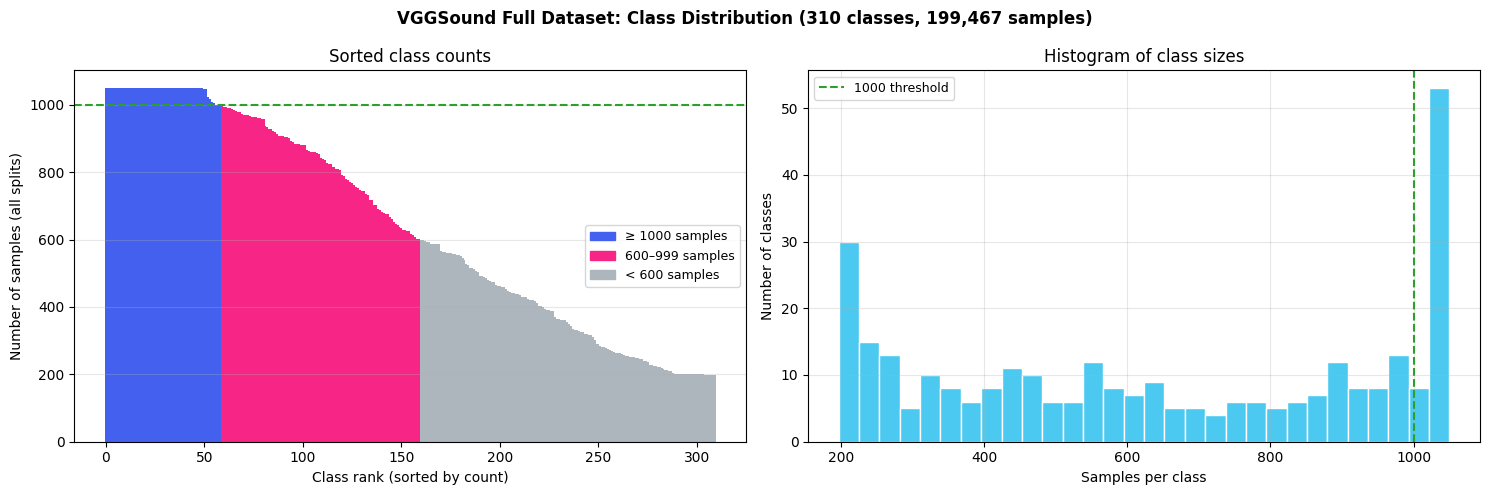

Classes with ≥ 1000 total samples: 59 / 310


In [22]:
sorted_counts = sorted(all_labels.values(), reverse=True)
x = np.arange(len(sorted_counts))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("VGGSound Full Dataset: Class Distribution (310 classes, 199,467 samples)",
             fontweight="bold")

# Bar chart (sorted)
colors = ["#4361ee" if c >= 1000 else ("#f72585" if c >= 600 else "#adb5bd")
          for c in sorted_counts]
ax1.bar(x, sorted_counts, color=colors, width=1.0)
ax1.axhline(1000, color="#2ca02c", linestyle="--", linewidth=1.5, label="1000 samples (target threshold)")
ax1.set_xlabel("Class rank (sorted by count)")
ax1.set_ylabel("Number of samples (all splits)")
ax1.set_title("Sorted class counts")
legend_patches = [
    mpatches.Patch(color="#4361ee", label="≥ 1000 samples"),
    mpatches.Patch(color="#f72585", label="600–999 samples"),
    mpatches.Patch(color="#adb5bd", label="< 600 samples"),
]
ax1.legend(handles=legend_patches, fontsize=9)
ax1.grid(True, alpha=0.3, axis="y")

# Histogram
ax2.hist(sorted_counts, bins=30, color="#4cc9f0", edgecolor="white")
ax2.axvline(1000, color="#2ca02c", linestyle="--", linewidth=1.5, label="1000 threshold")
ax2.set_xlabel("Samples per class")
ax2.set_ylabel("Number of classes")
ax2.set_title("Histogram of class sizes")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / "figures" / "eda_full_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

n_full = sum(1 for c in sorted_counts if c >= 1000)
print(f"Classes with ≥ 1000 total samples: {n_full} / {len(sorted_counts)}")

## 3. Identifying well-represented classes

To ensure reliable training, we need classes with enough **training** samples.
The target was 1,000 train samples per class (50 test), for a total of 1,050 per class.

We filter by **train split count ≥ 1,000**.

In [23]:
train_counts = collections.Counter(
    r["label"] for r in full_rows if r["split"] == "train"
)
test_counts = collections.Counter(
    r["label"] for r in full_rows if r["split"] == "test"
)

# Eligible: >= 1000 train AND >= 50 test
eligible = {
    lbl for lbl in all_labels
    if train_counts[lbl] >= 1000 and test_counts[lbl] >= 50
}

print(f"Classes with train ≥ 1000 AND test ≥ 50: {len(eligible)}")
print(f"\nFull list of eligible classes:")
for lbl in sorted(eligible):
    print(f"  train={train_counts[lbl]:4d}  test={test_counts[lbl]:3d}  → {lbl}")

Classes with train ≥ 1000 AND test ≥ 50: 45

Full list of eligible classes:
  train=1000  test= 50  → ambulance siren
  train=1000  test= 50  → basketball bounce
  train=1000  test= 50  → bird chirping, tweeting
  train=1000  test= 50  → chainsawing trees
  train=1000  test= 50  → chicken crowing
  train=1000  test= 50  → child speech, kid speaking
  train=1000  test= 50  → driving buses
  train=1000  test= 50  → driving motorcycle
  train=1000  test= 50  → engine accelerating, revving, vroom
  train=1000  test= 50  → female singing
  train=1000  test= 50  → female speech, woman speaking
  train=1000  test= 50  → fireworks banging
  train=1000  test= 50  → helicopter
  train=1000  test= 50  → male singing
  train=1000  test= 50  → male speech, man speaking
  train=1000  test= 50  → motorboat, speedboat acceleration
  train=1000  test= 50  → orchestra
  train=1000  test= 50  → people booing
  train=1000  test= 50  → people crowd
  train=1000  test= 50  → pigeon, dove cooing
  train=1000

## 4. Semantic grouping and subset selection

From the 45 eligible classes, **25** were chosen to ensure semantic diversity across
four macro-categories. The goal was to make the cross-modal distillation task truly
challenging, in order to do so we choose classes where visual and audio cues are sometimes decorrelated.

The 4 macro-categories and their chosen classes:

In [24]:
SEMANTIC_GROUPS = {
    "🎵 Musical Instruments (10)": [
        "playing acoustic guitar", "playing banjo", "playing cello",
        "playing cymbal", "playing drum kit", "playing flute",
        "playing harp", "playing piano", "playing saxophone",
        "playing violin, fiddle",
    ],
    "🚗 Vehicles & Machinery (5)": [
        "ambulance siren", "driving motorcycle",
        "engine accelerating, revving, vroom",
        "helicopter", "vehicle horn, car horn, honking",
    ],
    "🗣️ Human & Social Sounds (5)": [
        "female singing", "male speech, man speaking",
        "orchestra", "people booing", "fireworks banging",
    ],
    "🌿 Everyday & Nature Sounds (5)": [
        "basketball bounce", "bird chirping, tweeting",
        "chainsawing trees", "chicken crowing", "toilet flushing",
    ],
}

CHOSEN_25 = [cls for group in SEMANTIC_GROUPS.values() for cls in group]

print("Selected 25 classes by semantic group:\n")
for group, classes in SEMANTIC_GROUPS.items():
    print(f"{group}")
    for cls in classes:
        print(f"  • {cls}")
    print()

print(f"Total: {len(CHOSEN_25)} classes")

Selected 25 classes by semantic group:

🎵 Musical Instruments (10)
  • playing acoustic guitar
  • playing banjo
  • playing cello
  • playing cymbal
  • playing drum kit
  • playing flute
  • playing harp
  • playing piano
  • playing saxophone
  • playing violin, fiddle

🚗 Vehicles & Machinery (5)
  • ambulance siren
  • driving motorcycle
  • engine accelerating, revving, vroom
  • helicopter
  • vehicle horn, car horn, honking

🗣️ Human & Social Sounds (5)
  • female singing
  • male speech, man speaking
  • orchestra
  • people booing
  • fireworks banging

🌿 Everyday & Nature Sounds (5)
  • basketball bounce
  • bird chirping, tweeting
  • chainsawing trees
  • chicken crowing
  • toilet flushing

Total: 25 classes


/tmp/ipykernel_117882/181812342.py:35: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_117882/181812342.py:35: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_117882/181812342.py:35: UserWarning: Glyph 128483 (\N{SPEAKING HEAD IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_117882/181812342.py:35: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_117882/181812342.py:36: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.savefig(ROOT / "figures" / "eda_subset_selection.png", dpi=120, bbox_inches="tight")
/tmp/ipykernel_117882/181812342.py:36: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.savefig(ROOT / "figures" / "eda_subset_selection.png", dpi=120, bbox_inches="tight")
/tmp/ipykernel_117882/1

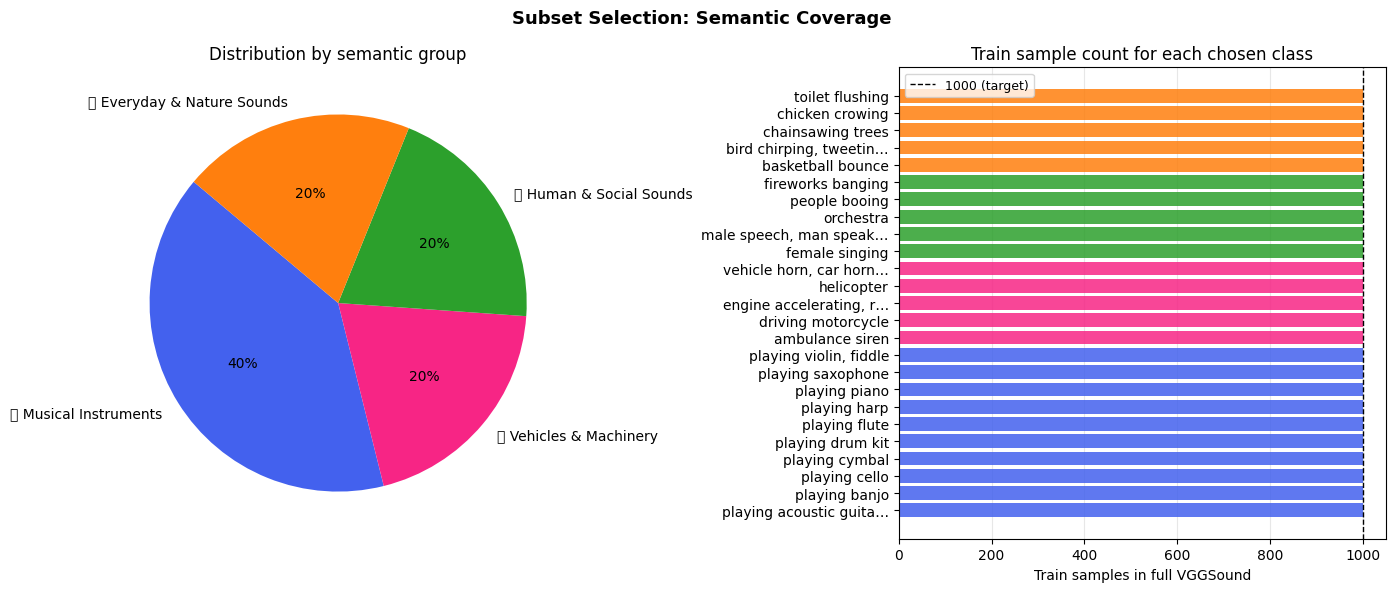


→ Selection completed successfully!
  In the next notebook (02_downloaded_subset_exploration), we will load the resulting subset.csv 
  generated by the download script and analyze its class balance and link-rot properties.


In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Subset Selection: Semantic Coverage", fontweight="bold", fontsize=13)

group_sizes = [len(v) for v in SEMANTIC_GROUPS.values()]
group_labels = [k.split(" (")[0] for k in SEMANTIC_GROUPS.keys()]
group_colors = ["#4361ee", "#f72585", "#2ca02c", "#ff7f0e"]

ax1.pie(group_sizes, labels=group_labels, colors=group_colors,
        autopct="%1.0f%%", startangle=140, textprops={"fontsize": 10})
ax1.set_title("Distribution by semantic group")

def find_count(label, counter):
    if label in counter:
        return counter[label]
    for key in counter:
        if key.strip('"') == label:
            return counter[key]
    return 0

bar_colors = []
for group, color in zip(SEMANTIC_GROUPS.keys(), group_colors):
    bar_colors.extend([color] * len(SEMANTIC_GROUPS[group]))

counts_chosen = [find_count(cls, train_counts) for cls in CHOSEN_25]
short_labels  = [cls[:22] + "…" if len(cls) > 22 else cls for cls in CHOSEN_25]

ax2.barh(short_labels, counts_chosen, color=bar_colors, alpha=0.85)
ax2.axvline(1000, color="black", linestyle="--", linewidth=1, label="1000 (target)")
ax2.set_xlabel("Train samples in full VGGSound")
ax2.set_title("Train sample count for each chosen class")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis="x")
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig(ROOT / "figures" / "eda_subset_selection.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n→ Selection completed successfully!")
print("  In the next notebook (02_downloaded_subset_exploration), we will load the resulting subset.csv ")
print("  generated by the download script and analyze its class balance and link-rot properties.")